# Notebook 2/2 — คำนวณ IoU, Confusion Matrix, F1-score และ Accuracy แบบกำหนดเอง (Custom)

สมุดบันทึกนี้เขียนกระบวนการคำนวณ **TP, FP, FN** ด้วยตนเองทีละขั้นตอน (ไม่ใช้ metric สำเร็จรูป)
เพื่อให้สามารถอธิบายวิธีการคำนวณในเล่มวิทยานิพนธ์ได้อย่างชัดเจน ครอบคลุม:

- **IoU (Intersection over Union)**
- **Confusion Matrix** (รวม background สำหรับ FP/FN)
- **Precision, Recall, F1-score**
- **Accuracy = TP / (TP + FP + FN)** — ตามที่กำหนด (สูตรนี้เป็นรูปแบบที่นิยมใช้ในงาน Object Detection
  แทน Accuracy แบบ classification ทั่วไป เพราะงาน detection ไม่มี True Negative (TN) ที่นับได้ชัดเจน)

---

## 1. สรุปสมการที่ใช้ในไฟล์นี้

**1) IoU ระหว่างกล่อง 2 กล่อง**

$$IoU(B_1, B_2) = \dfrac{|B_1 \cap B_2|}{|B_1 \cup B_2|} = \dfrac{|B_1 \cap B_2|}{|B_1| + |B_2| - |B_1 \cap B_2|}$$

**2) กติกาการตัดสิน TP / FP / FN** (ต่อ 1 คลาส, ที่ IoU threshold ที่กำหนด เช่น 0.5)

- **TP (True Positive)**: กล่องที่โมเดลทำนาย จับคู่ได้กับกล่อง Ground Truth คลาสเดียวกัน โดยมี $IoU \ge threshold$
  (จับคู่แบบ greedy: เรียง prediction ตาม confidence มากไปน้อย แล้วจับคู่กับ GT ที่ IoU สูงสุดที่ยังไม่ถูกจับคู่)
- **FP (False Positive)**: กล่องที่โมเดลทำนาย แต่ไม่มี GT ให้จับคู่ได้ (ไม่มี GT เหลือ หรือ IoU กับทุก GT ต่ำกว่า threshold)
- **FN (False Negative)**: กล่อง Ground Truth ที่ไม่มีการทำนายใดจับคู่ได้เลย (โมเดลตรวจไม่เจอ)

**3) Precision**

$$Precision = \dfrac{TP}{TP + FP}$$

**4) Recall**

$$Recall = \dfrac{TP}{TP + FN}$$

**5) F1-score** (ค่าเฉลี่ยฮาร์โมนิกของ Precision และ Recall)

$$F1 = 2 \times \dfrac{Precision \times Recall}{Precision + Recall} = \dfrac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

**6) Accuracy (ตามที่โจทย์กำหนด สำหรับงาน detection)**

$$Accuracy = \dfrac{TP}{TP + FP + FN}$$

> หมายเหตุ: สูตรนี้ต่างจาก Accuracy แบบ classification ทั่วไป ($\frac{TP+TN}{TP+TN+FP+FN}$)
> เนื่องจากในงาน object detection ไม่มีนิยามของ True Negative (พื้นที่ที่ "ไม่มีวัตถุ" มีจำนวนอนันต์/ไม่ถูกนับ)
> จึงตัด TN ออกจากสมการ

**7) Confusion Matrix**

เป็นตารางขนาด $(N_{class}+1) \times (N_{class}+1)$ (แถว/คอลัมน์พิเศษ = "background")
- แถว = คลาสที่ทำนาย (Predicted)
- คอลัมน์ = คลาสจริง (Ground Truth)
- ตำแหน่งทแยงมุม = TP ของแต่ละคลาส
- แถว "background" คอลัมน์คลาส c = FN ของคลาส c (โมเดลไม่ทำนายเลย)
- คอลัมน์ "background" แถวคลาส c = FP ของคลาส c (โมเดลทำนายเกิน/ผิดตำแหน่ง)

---


## 2. Import ไลบรารีและตั้งค่า

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

from ultralytics import YOLO


In [2]:
# --- แก้ไข path ให้ตรงกับเครื่องของคุณ ---
MODEL_PATH   = r"D:\license_plate_and_car_detection\runs\detect\YOLO\License_Province3_320\weights\best.onnx"
TEST_IMAGES_DIR = r"D:\license_plate_and_car_detection\dataset_plate_100\test\images"
TEST_LABELS_DIR = r"D:\license_plate_and_car_detection\dataset_plate_100\test\labels"  # โฟลเดอร์ label (.txt รูปแบบ YOLO) คู่กับรูปชุด test

CLASS_NAMES = ['car', 'license-plate']   # ต้องตรงกับลำดับใน data.yaml -> names
NUM_CLASSES = len(CLASS_NAMES)

IOU_THRESHOLD  = 0.7    # threshold สำหรับตัดสิน TP (ตรงกับ mAP@50)
CONF_THRESHOLD = 0.7   # confidence ขั้นต่ำที่จะนับว่าเป็นการทำนาย (ใช้ค่าที่จะ deploy จริง)

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

assert os.path.isdir(TEST_IMAGES_DIR), f"ไม่พบโฟลเดอร์รูป: {TEST_IMAGES_DIR}"
assert os.path.isdir(TEST_LABELS_DIR), f"ไม่พบโฟลเดอร์ label: {TEST_LABELS_DIR}"

image_paths = sorted([p for p in glob.glob(os.path.join(TEST_IMAGES_DIR, "*")) if p.lower().endswith(IMG_EXTS)])
print(f"พบรูปภาพชุด test ทั้งหมด {len(image_paths)} ไฟล์")


พบรูปภาพชุด test ทั้งหมด 100 ไฟล์


## 3. ฟังก์ชันอ่านไฟล์ label รูปแบบ YOLO (.txt) และแปลงเป็นพิกัด (x1, y1, x2, y2)

In [3]:
def yolo_txt_to_xyxy(label_path, img_w, img_h):
    """อ่านไฟล์ label รูปแบบ YOLO: 'class x_center y_center width height' (ค่า normalized 0-1)
    คืนค่าเป็น list ของ (class_id, x1, y1, x2, y2) พิกัดจริง (pixel)"""
    boxes = []
    if not os.path.exists(label_path):
        return boxes  # ไม่มี object ในรูปนี้
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            cls_id = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
            x1 = (xc - w / 2) * img_w
            y1 = (yc - h / 2) * img_h
            x2 = (xc + w / 2) * img_w
            y2 = (yc + h / 2) * img_h
            boxes.append((cls_id, x1, y1, x2, y2))
    return boxes


## 4. ฟังก์ชันคำนวณ IoU

ตามสมการข้อ 1) ในหัวข้อสรุปสมการด้านบน


In [4]:
def compute_iou(box1, box2):
    """box = (x1, y1, x2, y2) พิกัด pixel จริง คืนค่า IoU (float ระหว่าง 0-1)"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])
    union_area = area1 + area2 - inter_area

    if union_area <= 0:
        return 0.0
    return inter_area / union_area


## 5. รัน inference บนทุกภาพในชุด test แล้วจับคู่ Prediction กับ Ground Truth (Greedy Matching)

ขั้นตอน:
1. รันโมเดลทำนายกล่องในแต่ละภาพ
2. อ่าน Ground Truth ของภาพเดียวกัน
3. เรียง prediction ตาม confidence จากมากไปน้อย แล้วจับคู่กับ GT คลาสเดียวกันที่ IoU สูงสุดและยังไม่ถูกจับคู่
   ถ้า IoU ≥ threshold → เป็น TP มิฉะนั้น → FP
4. GT ที่เหลือไม่ถูกจับคู่เลย → FN
5. สะสมผลลัพธ์ลงใน Confusion Matrix และ list ของ IoU ที่จับคู่ได้ (สำหรับดู IoU เฉลี่ย)


In [5]:
model = YOLO(MODEL_PATH)

# confusion_matrix[i, j] = ทำนายเป็นคลาส i แต่จริงคือคลาส j
# index สุดท้าย (NUM_CLASSES) = 'background'
confusion_matrix = np.zeros((NUM_CLASSES + 1, NUM_CLASSES + 1), dtype=int)

matched_ious = []          # เก็บค่า IoU ของคู่ที่จับคู่เป็น TP ได้ (ไว้คำนวณ IoU เฉลี่ย)
per_class_tp = np.zeros(NUM_CLASSES, dtype=int)
per_class_fp = np.zeros(NUM_CLASSES, dtype=int)
per_class_fn = np.zeros(NUM_CLASSES, dtype=int)

BG = NUM_CLASSES  # index แทน background

for img_path in image_paths:
    result = model.predict(img_path, conf=CONF_THRESHOLD, verbose=False)[0]
    img_h, img_w = result.orig_shape

    # --- ground truth ---
    fname = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(TEST_LABELS_DIR, fname + ".txt")
    gt_boxes = yolo_txt_to_xyxy(label_path, img_w, img_h)   # [(cls, x1,y1,x2,y2), ...]
    gt_matched = [False] * len(gt_boxes)

    # --- predictions เรียงตาม confidence มากไปน้อย ---
    pred_list = []
    if result.boxes is not None and len(result.boxes) > 0:
        xyxy = result.boxes.xyxy.cpu().numpy()
        cls_ids = result.boxes.cls.cpu().numpy().astype(int)
        confs = result.boxes.conf.cpu().numpy()
        for (x1, y1, x2, y2), c, conf in zip(xyxy, cls_ids, confs):
            pred_list.append((conf, c, x1, y1, x2, y2))
    pred_list.sort(key=lambda t: t[0], reverse=True)  # confidence มาก -> น้อย

    for conf, p_cls, x1, y1, x2, y2 in pred_list:
        best_iou = 0.0
        best_gt_idx = -1
        for gi, (g_cls, gx1, gy1, gx2, gy2) in enumerate(gt_boxes):
            if gt_matched[gi] or g_cls != p_cls:
                continue
            iou = compute_iou((x1, y1, x2, y2), (gx1, gy1, gx2, gy2))
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gi

        if best_iou >= IOU_THRESHOLD and best_gt_idx != -1:
            # TP
            gt_matched[best_gt_idx] = True
            confusion_matrix[p_cls, p_cls] += 1
            per_class_tp[p_cls] += 1
            matched_ious.append(best_iou)
        else:
            # FP: ทำนายเกินมา ไม่มี GT รองรับ
            confusion_matrix[p_cls, BG] += 1
            per_class_fp[p_cls] += 1

    # GT ที่ไม่ถูกจับคู่เลย -> FN
    for gi, matched in enumerate(gt_matched):
        if not matched:
            g_cls = gt_boxes[gi][0]
            confusion_matrix[BG, g_cls] += 1
            per_class_fn[g_cls] += 1

print("ประมวลผลครบทุกภาพแล้ว:", len(image_paths), "ภาพ")


Loading D:\license_plate_and_car_detection\runs\detect\YOLO\License_Province3_320\weights\best.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.23.2 with CUDAExecutionProvider
ประมวลผลครบทุกภาพแล้ว: 100 ภาพ


## 6. คำนวณ Precision, Recall, F1-score, Accuracy และ IoU เฉลี่ย (ตามสมการในหัวข้อ 1)

In [6]:
rows = []
for i, name in enumerate(CLASS_NAMES):
    tp, fp, fn = per_class_tp[i], per_class_fp[i], per_class_fn[i]
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    accuracy  = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    rows.append({
        "class": name, "TP": tp, "FP": fp, "FN": fn,
        "Precision": round(precision, 4), "Recall": round(recall, 4),
        "F1-score": round(f1, 4), "Accuracy": round(accuracy, 4),
    })

# ภาพรวม (micro-average: รวม TP/FP/FN ทุกคลาสก่อนคำนวณ)
TP_all, FP_all, FN_all = per_class_tp.sum(), per_class_fp.sum(), per_class_fn.sum()
precision_all = TP_all / (TP_all + FP_all) if (TP_all + FP_all) > 0 else 0.0
recall_all    = TP_all / (TP_all + FN_all) if (TP_all + FN_all) > 0 else 0.0
f1_all        = (2 * precision_all * recall_all / (precision_all + recall_all)) if (precision_all + recall_all) > 0 else 0.0
accuracy_all  = TP_all / (TP_all + FP_all + FN_all) if (TP_all + FP_all + FN_all) > 0 else 0.0
mean_iou      = float(np.mean(matched_ious)) if len(matched_ious) > 0 else 0.0

rows.append({
    "class": "ALL (micro-avg)", "TP": TP_all, "FP": FP_all, "FN": FN_all,
    "Precision": round(precision_all, 4), "Recall": round(recall_all, 4),
    "F1-score": round(f1_all, 4), "Accuracy": round(accuracy_all, 4),
})

df_custom = pd.DataFrame(rows)
print(df_custom.to_string(index=False))
print(f"\nIoU เฉลี่ยของคู่ที่จับคู่เป็น TP (Mean IoU @ matched pairs) = {mean_iou:.4f}")

df_custom.to_csv("custom_metrics_summary.csv", index=False)


          class  TP  FP  FN  Precision  Recall  F1-score  Accuracy
            car  99   0   1     1.0000    0.99    0.9950    0.9900
  license-plate  73   2  27     0.9733    0.73    0.8343    0.7157
ALL (micro-avg) 172   2  28     0.9885    0.86    0.9198    0.8515

IoU เฉลี่ยของคู่ที่จับคู่เป็น TP (Mean IoU @ matched pairs) = 0.9252


## 7. Confusion Matrix — ตารางตัวเลข และกราฟ Heatmap

In [7]:
labels_with_bg = CLASS_NAMES + ["background"]
cm_df = pd.DataFrame(confusion_matrix, index=labels_with_bg, columns=labels_with_bg)
cm_df.index.name = "Predicted \\ Actual"
print(cm_df)
cm_df.to_csv("confusion_matrix.csv")


                    car  license-plate  background
Predicted \ Actual                                
car                  99              0           0
license-plate         0             73           2
background            1             27           0


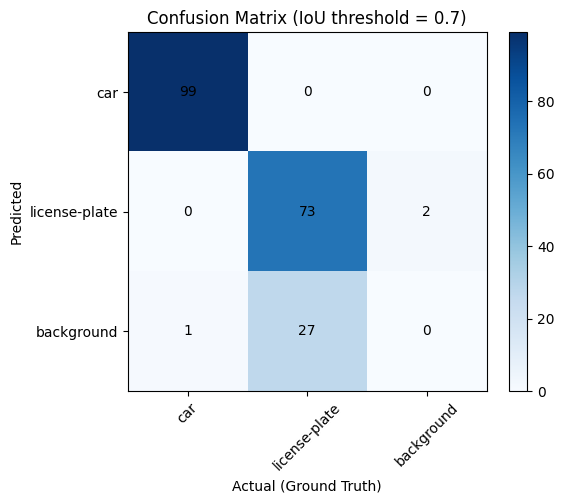

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
if HAS_SEABORN:
    sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_with_bg, yticklabels=labels_with_bg, ax=ax)
else:
    im = ax.imshow(confusion_matrix, cmap="Blues")
    ax.set_xticks(range(len(labels_with_bg))); ax.set_xticklabels(labels_with_bg, rotation=45)
    ax.set_yticks(range(len(labels_with_bg))); ax.set_yticklabels(labels_with_bg)
    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            ax.text(j, i, confusion_matrix[i, j], ha="center", va="center")
    fig.colorbar(im)

ax.set_xlabel("Actual (Ground Truth)")
ax.set_ylabel("Predicted")
ax.set_title(f"Confusion Matrix (IoU threshold = {IOU_THRESHOLD})")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()


## 8. สรุปผลทั้งหมด (สำหรับคัดลอกไปใส่เล่ม)

ตารางด้านล่างรวมทุก metric ที่คำนวณแบบ custom ในไฟล์นี้ ได้แก่ TP, FP, FN, Precision, Recall, F1-score,
Accuracy = TP/(TP+FP+FN) และค่า IoU เฉลี่ยของคู่ที่จับคู่กันได้ (mean matched IoU)


In [9]:
summary = {
    "IoU threshold ที่ใช้ตัดสิน TP": IOU_THRESHOLD,
    "Confidence threshold": CONF_THRESHOLD,
    "จำนวนภาพชุด test": len(image_paths),
    "Mean IoU (matched TP pairs)": round(mean_iou, 4),
    "Precision (micro-avg)": round(precision_all, 4),
    "Recall (micro-avg)": round(recall_all, 4),
    "F1-score (micro-avg)": round(f1_all, 4),
    "Accuracy = TP/(TP+FP+FN) (micro-avg)": round(accuracy_all, 4),
}
for k, v in summary.items():
    print(f"{k:45s}: {v}")


IoU threshold ที่ใช้ตัดสิน TP                : 0.7
Confidence threshold                         : 0.7
จำนวนภาพชุด test                             : 100
Mean IoU (matched TP pairs)                  : 0.9252
Precision (micro-avg)                        : 0.9885
Recall (micro-avg)                           : 0.86
F1-score (micro-avg)                         : 0.9198
Accuracy = TP/(TP+FP+FN) (micro-avg)         : 0.8515
